### Imports and paths ###

In [77]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

DATA_DIR = BASE_DIR / 'data'
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / "processed"
IMAGE_DIR = BASE_DIR / "images"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = RAW_DIR / "hotels.csv"
DATA_PATH


WindowsPath('c:/Users/M.SRIMANREDDY/OneDrive/Desktop/DT+RF/data/raw/hotels.csv')

### Download Dataset ###

In [78]:
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2020/2020-02-11/hotels.csv"

if not DATA_PATH.exists():
    df_raw = pd.read_csv(url)
    df_raw.to_csv(DATA_PATH, index=False)
    print("Dataset downloaded and saved.")
else:
    print("Dataset already exists.")

Dataset already exists.


### Load Data ###

In [79]:
df = pd.read_csv(DATA_PATH)

df.columns = (
    df.columns.str.strip().str.lower().str.replace(" ", "_")
)
print("shape", df.shape)
df.head()

shape (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### Dataset_overview ###

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [81]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0
adults,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0


### Target variable check ###

In [82]:
target = 'is_canceled'

target_counts = df[target].value_counts()
target_percent = df[target].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'count': target_counts,
    'percent': target_percent
})
(target_summary)

,count,percent
is_canceled,,
0,75166,62.958372
1,44224,37.041628


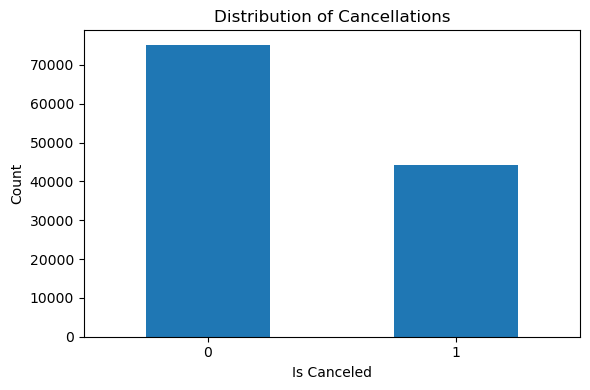

In [83]:
plt.figure(figsize=(6, 4))
target_counts.plot(kind='bar')
plt.title('Distribution of Cancellations')
plt.xlabel('Is Canceled')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Missing values ###

In [84]:
missing_summary = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': df.isnull().mean() * 100
}).sort_values(by='missing_percent', ascending=False)
missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_percent
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


### Duplicate rows ###

In [85]:
duplicate_count = df.duplicated().sum()
duplicated_percent = (duplicate_count / len(df)) * 100
print(f"Duplicate rows: {duplicate_count}",f"Duplicated_percentage : ({duplicated_percent:.2f}%)")

Duplicate rows: 31994 Duplicated_percentage : (26.80%)


### check leakeage columns ###

In [86]:
leakage_columns = ['reservation_status', 'reservation_status_date']
df[leakage_columns].head()

,reservation_status,reservation_status_date
0,Check-Out,2015-07-01
1,Check-Out,2015-07-01
2,Check-Out,2015-07-02
3,Check-Out,2015-07-02
4,Check-Out,2015-07-03


In [87]:
df['reservation_status'].value_counts()

reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64

### Numeric and categorical columns ###

In [88]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_columns = df.select_dtypes(include=['object','category','bool']).columns.tolist()

print("Numeric columns:", numeric_columns)
print('Number of numeric columns:', len(numeric_columns))
print("Categorical columns:", categorical_columns)
print('Number of categorical columns:', len(categorical_columns))

Numeric columns: ['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
Number of numeric columns: 20
Categorical columns: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']
Number of categorical columns: 12


### Cancellation rate helper function ###

In [89]:
def cancellation_rate_by_column(data, column, target='is_canceled', top_n = 15):
    result=(
        data.groupby(column)[target].agg(['count','mean']).sort_values(by='mean', ascending=False))
    
    result["cancellation_rate_%"] = result['mean'] * 100
    result = result.rename(columns={'count': 'booking_count'})
    result = result.drop(columns=['mean'])
    return result.head(top_n)

### Cancellation by hotel type ###

In [90]:
hotel_cancel = cancellation_rate_by_column(df, 'hotel')
hotel_cancel

,booking_count,cancellation_rate_%
hotel,,
City Hotel,79330,41.726963
Resort Hotel,40060,27.763355


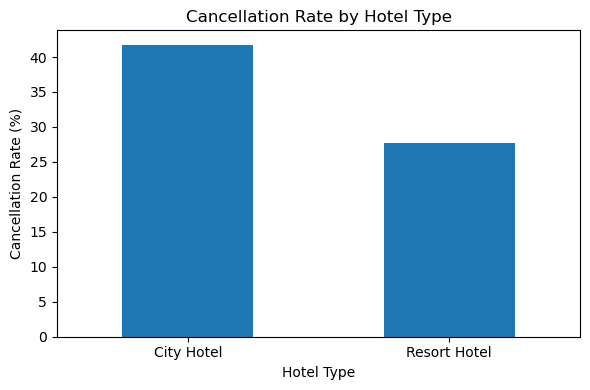

In [91]:
hotel_cancel['cancellation_rate_%'].plot(kind='bar', figsize=(6, 4))
plt.title('Cancellation Rate by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Cancellation by deposit type ###

In [92]:
deposit_cancel = cancellation_rate_by_column(df, 'deposit_type')
deposit_cancel

,booking_count,cancellation_rate_%
deposit_type,,
Non Refund,14587,99.362446
No Deposit,104641,28.377022
Refundable,162,22.222222


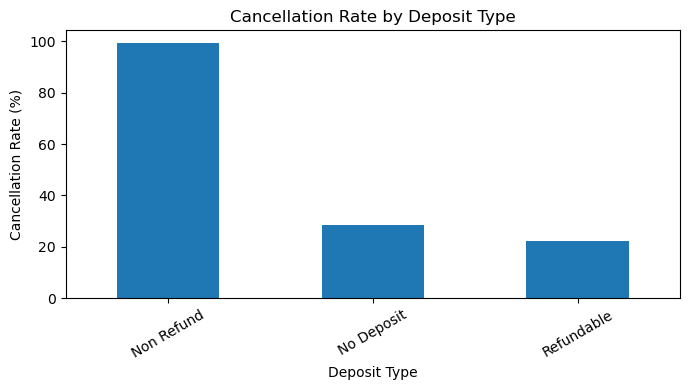

In [93]:
deposit_cancel["cancellation_rate_%"].plot(kind="bar", figsize=(7, 4))
plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Cancellation by customer type ### 

In [94]:
customer_cancel = cancellation_rate_by_column(df, 'customer_type')
customer_cancel

,booking_count,cancellation_rate_%
customer_type,,
Transient,89613,40.746320
Contract,4076,30.961727
Transient-Party,25124,25.429868
Group,577,10.225303


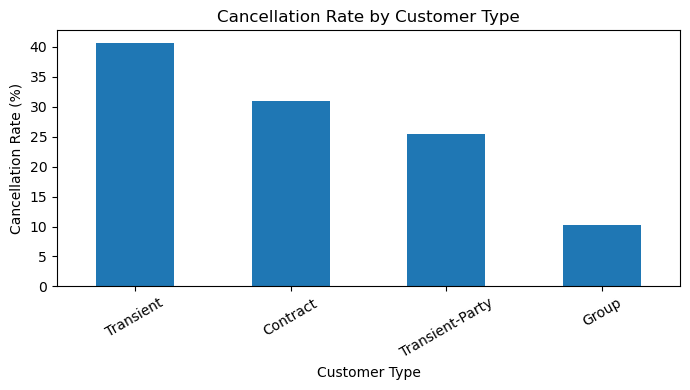

In [95]:
customer_cancel["cancellation_rate_%"].plot(kind="bar", figsize=(7, 4))
plt.title("Cancellation Rate by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### cancellation by market segment ###

In [96]:
market_cancel = cancellation_rate_by_column(df, "market_segment")
market_cancel

,booking_count,cancellation_rate_%
market_segment,,
Undefined,2,100.000000
Groups,19811,61.062036
Online TA,56477,36.721143
Offline TA/TO,24219,34.316033
Aviation,237,21.940928
Corporate,5295,18.734655
Direct,12606,15.341901
Complementary,743,13.055182


### Lead time analysis ###

In [97]:
df['lead_time'].describe()

count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64

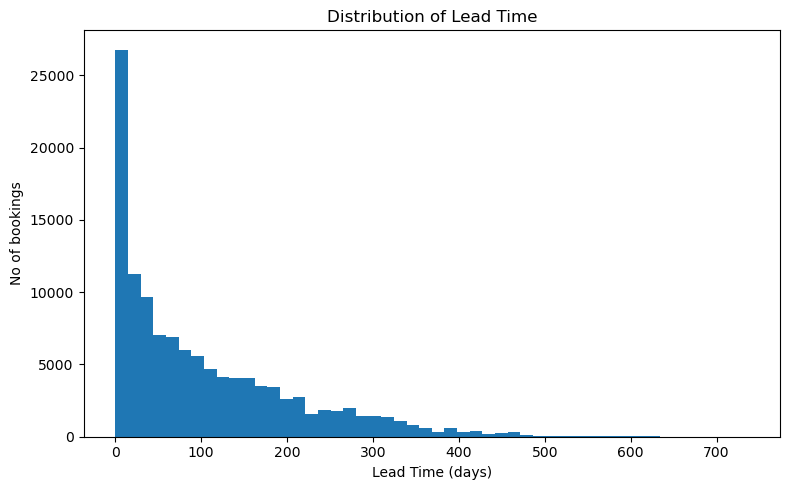

In [98]:
plt.figure(figsize=(8, 5))
plt.hist(df['lead_time'], bins = 50)
plt.title('Distribution of Lead Time')
plt.xlabel('Lead Time (days)')
plt.ylabel('No of bookings')
plt.tight_layout()
plt.show()

In [99]:
df["lead_time_group"] = pd.cut(
    df["lead_time"],
    bins=[-1, 7, 30, 90, 180, 365, df["lead_time"].max()],
    labels=["0-7 days", "8-30 days", "31-90 days", "91-180 days", "181-365 days", "365+ days"]
)

lead_time_cancel = cancellation_rate_by_column(df, "lead_time_group")
lead_time_cancel

C:\Users\M.SRIMANREDDY\AppData\Local\Temp\ipykernel_15308\3745535804.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(column)[target].agg(['count','mean']).sort_values(by='mean', ascending=False))


,booking_count,cancellation_rate_%
lead_time_group,,
365+ days,3148,67.662008
181-365 days,21544,55.453955
91-180 days,26439,44.710466
31-90 days,29553,37.698372
8-30 days,18960,27.863924
0-7 days,19746,9.632331


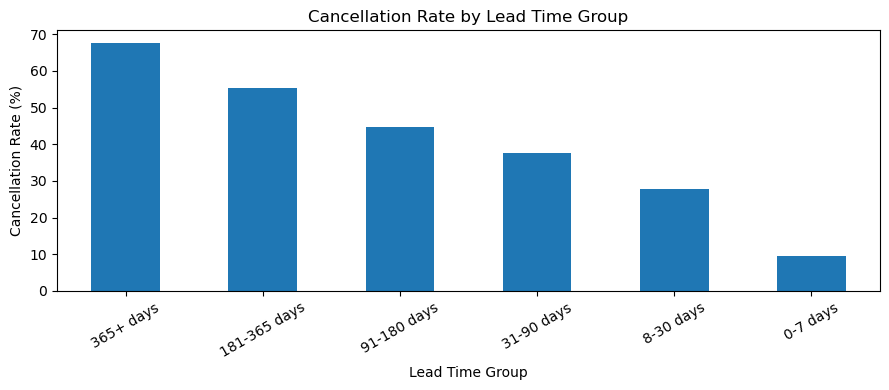

In [100]:
lead_time_cancel["cancellation_rate_%"].plot(kind="bar", figsize=(9, 4))
plt.title("Cancellation Rate by Lead Time Group")
plt.xlabel("Lead Time Group")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### ADR Analysis ###

In [101]:
df['adr'].describe()

count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

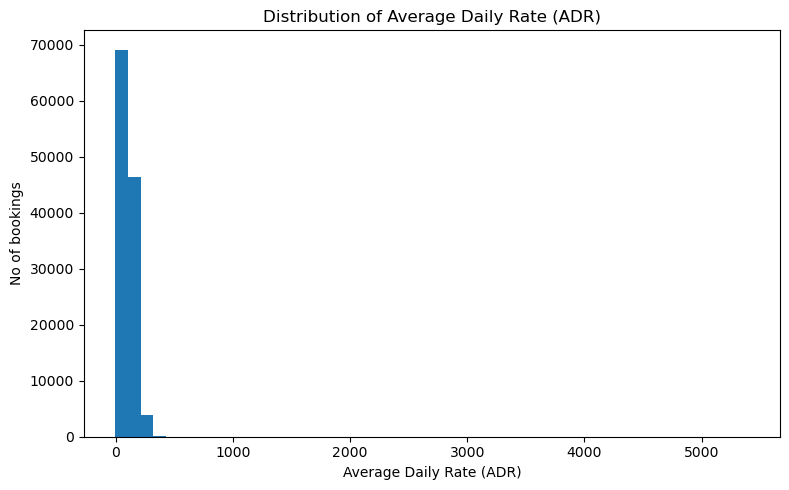

In [102]:
plt.figure(figsize=(8,5))
plt.hist(df['adr'], bins=50)
plt.title('Distribution of Average Daily Rate (ADR)')
plt.xlabel('Average Daily Rate (ADR)')
plt.ylabel('No of bookings')
plt.tight_layout()
plt.show()

### special requests analysis ###

In [103]:
request_cancel = cancellation_rate_by_column(df, 'total_of_special_requests')
request_cancel

,booking_count,cancellation_rate_%
total_of_special_requests,,
0,70318,47.720356
2,12969,22.098851
1,33226,22.024920
3,2497,17.861434
4,340,10.588235
5,40,5.000000


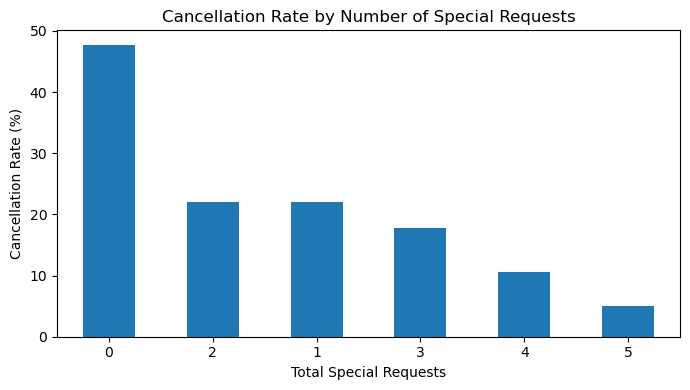

In [104]:
request_cancel["cancellation_rate_%"].plot(kind="bar", figsize=(7, 4))
plt.title("Cancellation Rate by Number of Special Requests")
plt.xlabel("Total Special Requests")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Arrival month analysis ###

In [105]:
month_cancel = cancellation_rate_by_column(df, 'arrival_date_month', top_n=12)
month_cancel

,booking_count,cancellation_rate_%
arrival_date_month,,
June,10939,41.457172
April,11089,40.797186
May,11791,39.665847
September,10508,39.170156
October,11160,38.046595
August,13877,37.753117
July,12661,37.453598
December,6780,34.970501
February,8068,33.415964


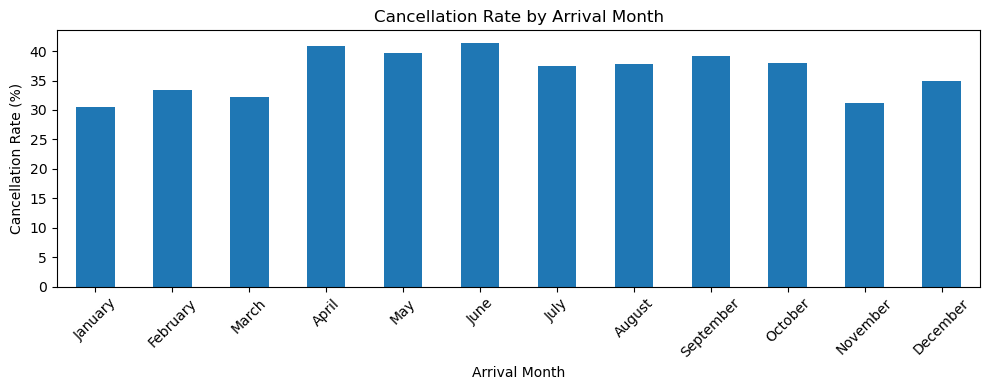

In [107]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
month_cancel_ordered = (
    df.groupby('arrival_date_month')['is_canceled']
    .mean().reindex(month_order) * 100
)

month_cancel_ordered.plot(kind="bar", figsize=(10, 4))
plt.title("Cancellation Rate by Arrival Month")
plt.xlabel("Arrival Month")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [108]:
eda_output_path = PROCESSED_DIR / "hotels_eda_ready.csv"

df.to_csv(eda_output_path, index=False)

print("Saved EDA-ready dataset to:", eda_output_path)

Saved EDA-ready dataset to: c:\Users\M.SRIMANREDDY\OneDrive\Desktop\DT+RF\data\processed\hotels_eda_ready.csv
